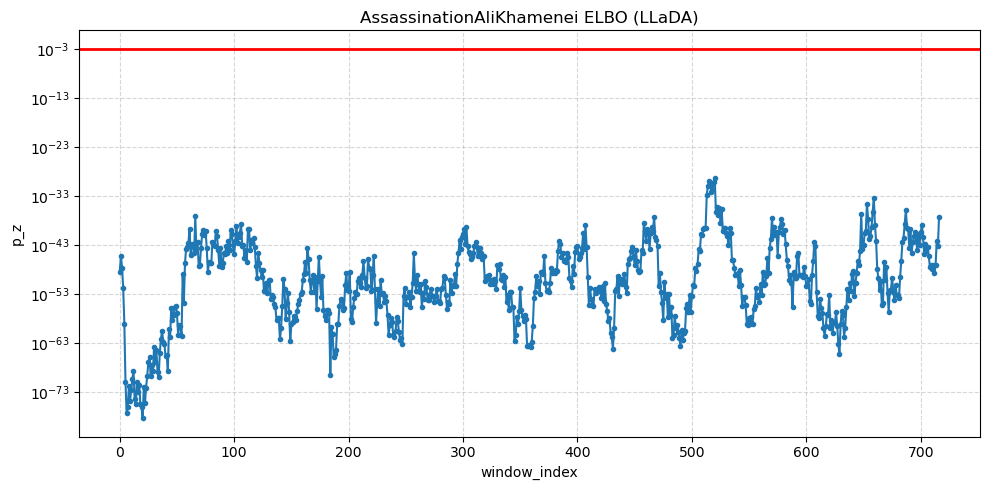

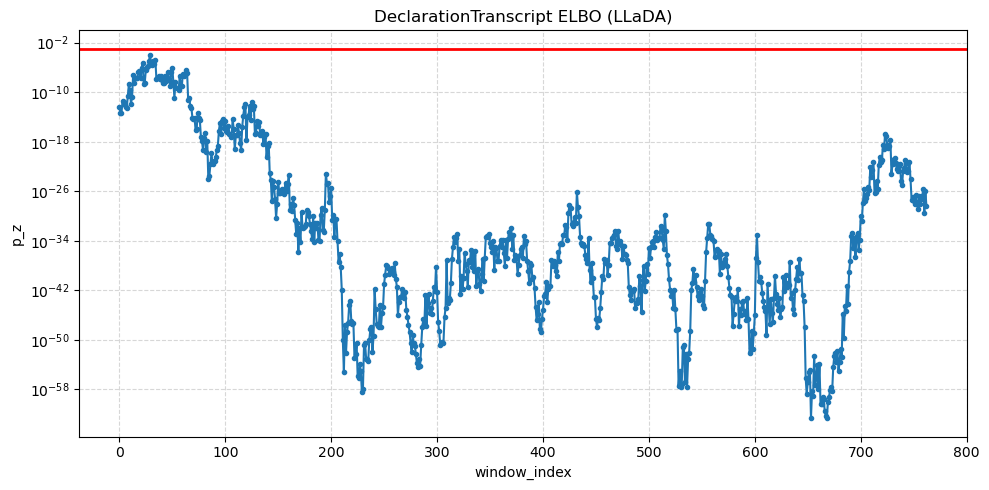

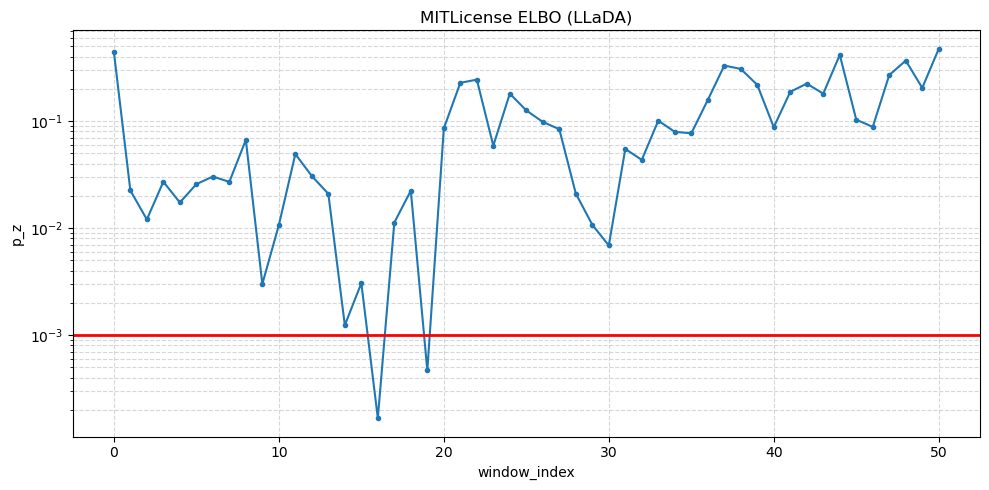

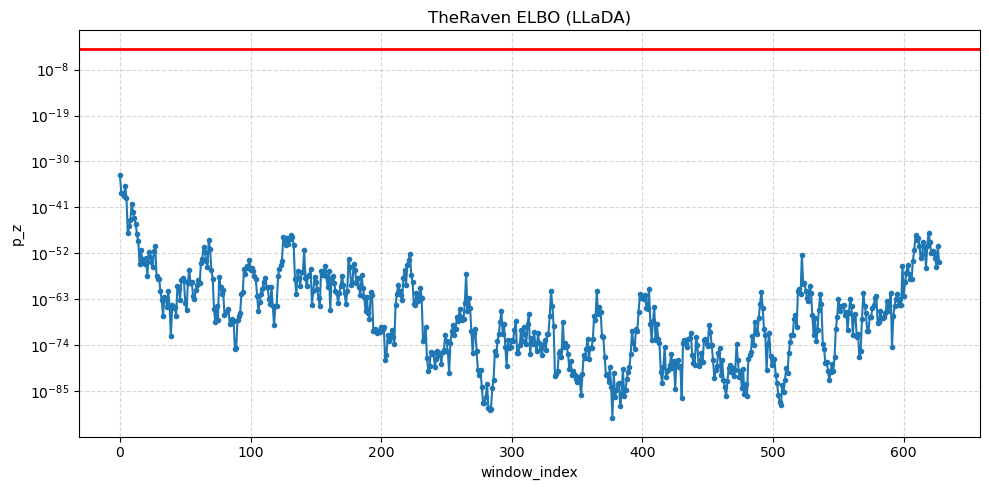

00000000000000000000 50+5 AssassinationAliKhamenei temp = 0 low-confidence remasking (LLaDA)
00000000000000000000 50+50 AssassinationAliKhamenei temp = 0 low-confidence remasking (LLaDA)
00000000000000000000 50+5 DeclarationTranscript temp = 0 low-confidence remasking (LLaDA)
00000000000000000000 50+50 DeclarationTranscript temp = 0 low-confidence remasking (LLaDA)


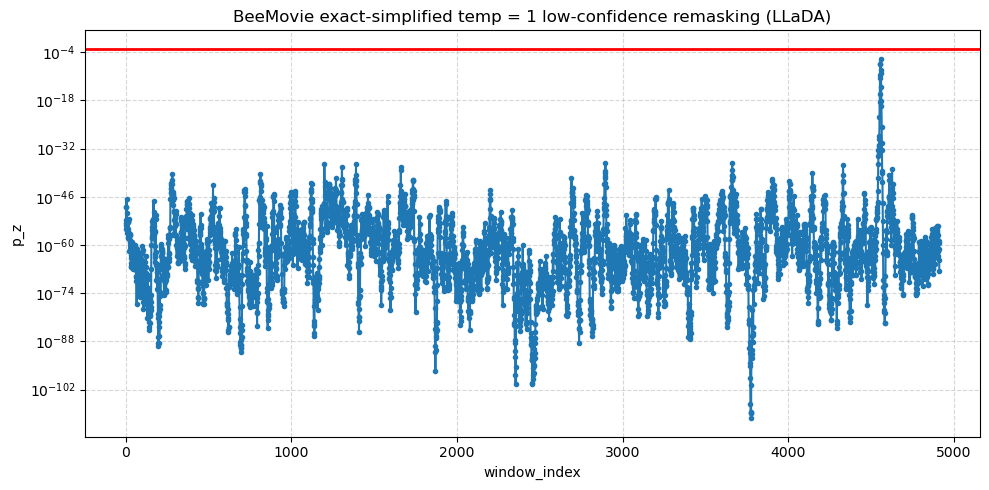

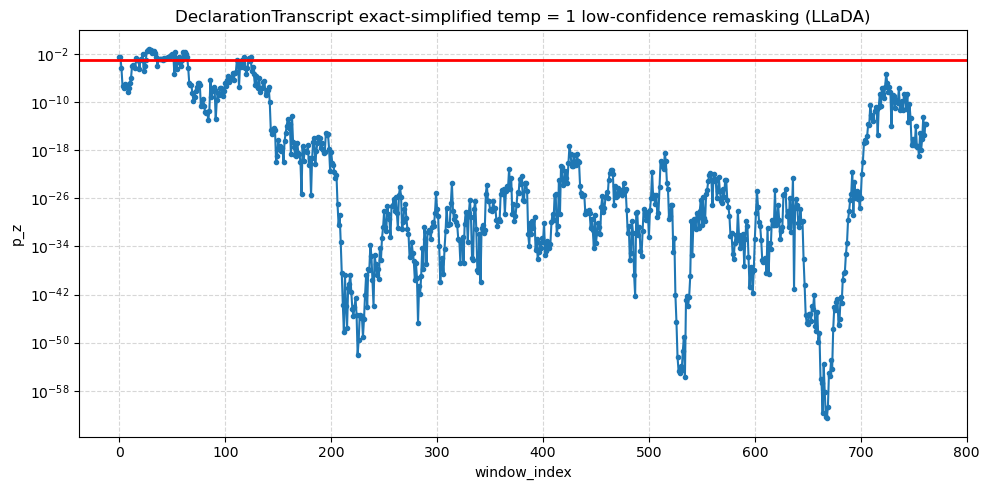

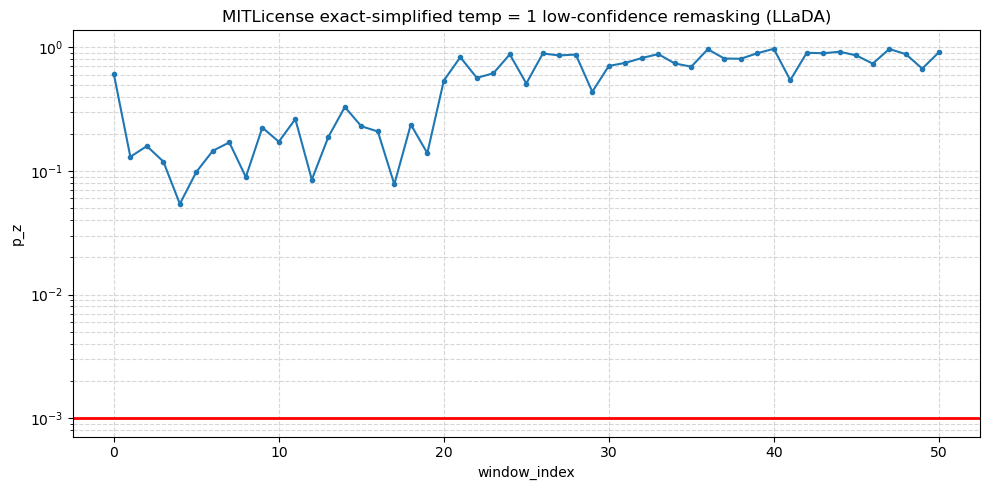

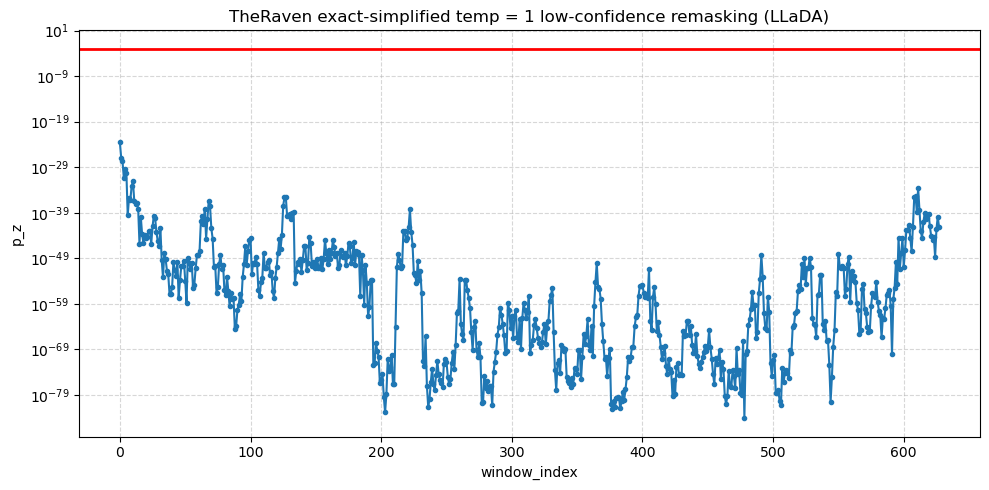

Skipping AssassinationAliKhamenei full temp = 1 low-confidence remasking (LLaDA): no positive p_z values for log scale
Skipping BeeMovie full temp = 1 low-confidence remasking (LLaDA): no positive p_z values for log scale


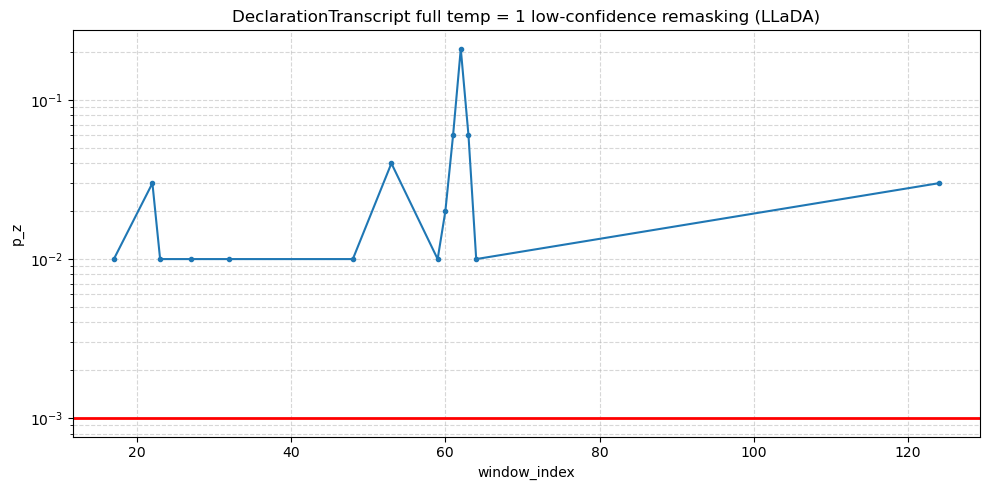

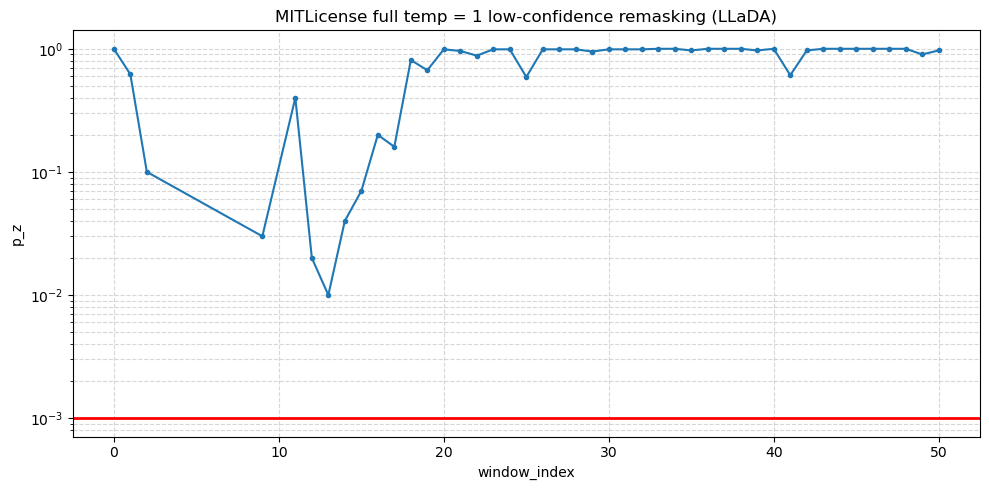

Skipping TheRaven full temp = 1 low-confidence remasking (LLaDA): no positive p_z values for log scale
00000000000000000000 AssassinationAliKhamenei top_k = 40 temp = 1 low-confidence remasking (LLaDA)
00000000000000000000 BeeMovie top_k = 40 temp = 1 low-confidence remasking (LLaDA)
00000000000000000000 DeclarationTranscript top_k = 40 temp = 1 low-confidence remasking (LLaDA)
00000000000000000000 MITLicense top_k = 40 temp = 1 low-confidence remasking (LLaDA)
00000000000000000000 TheRaven top_k = 40 temp = 1 low-confidence remasking (LLaDA)


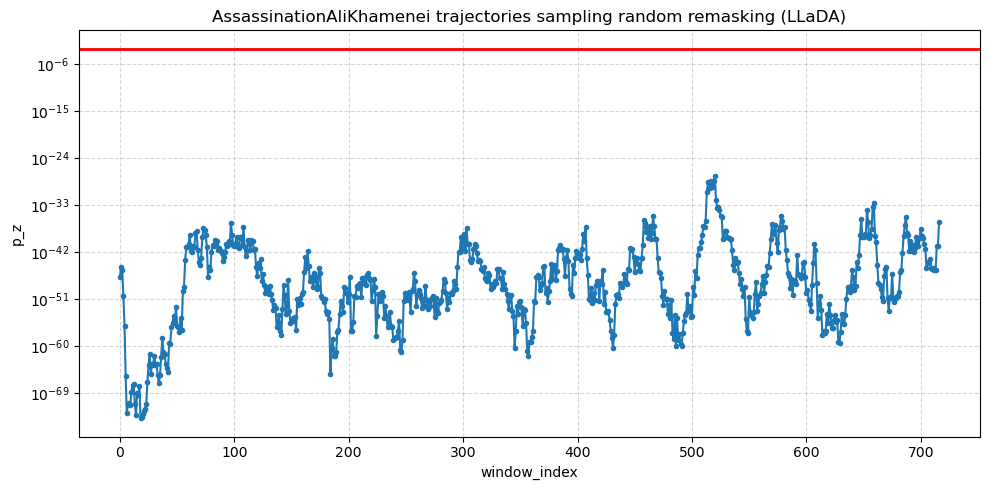

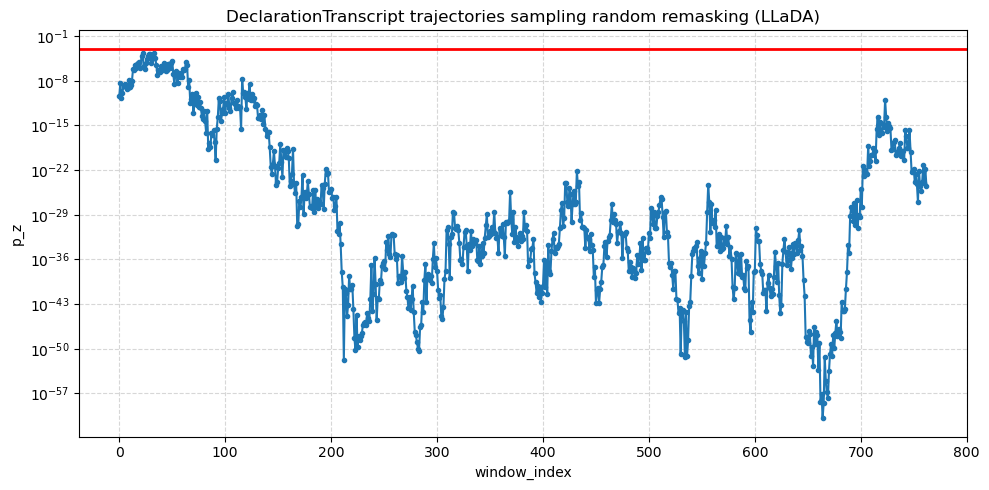

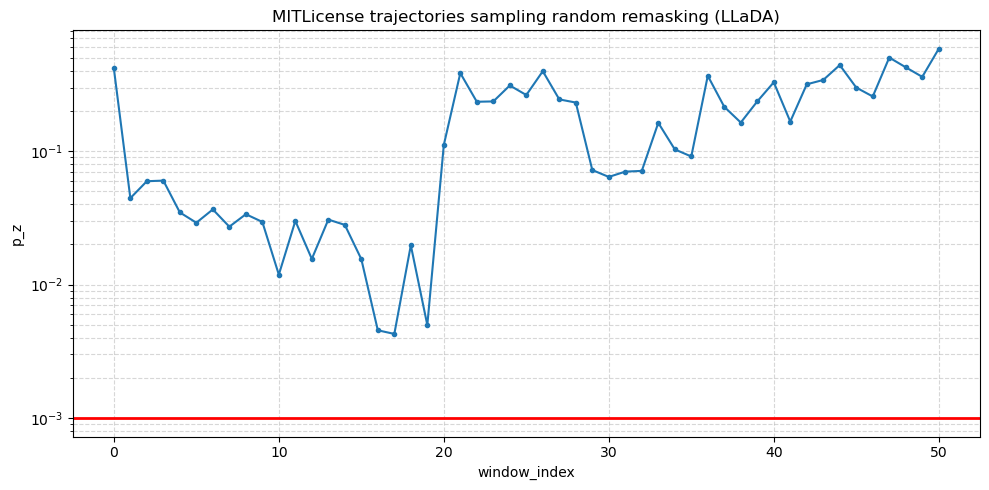

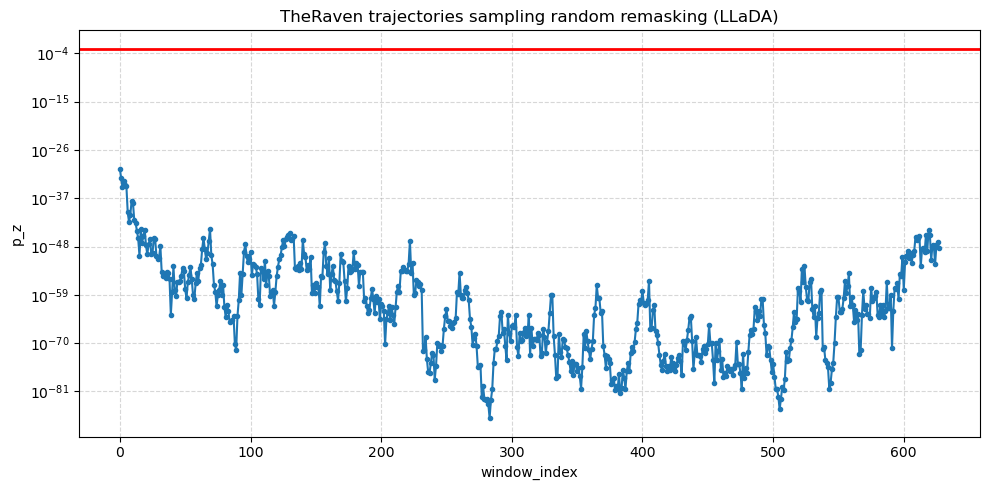

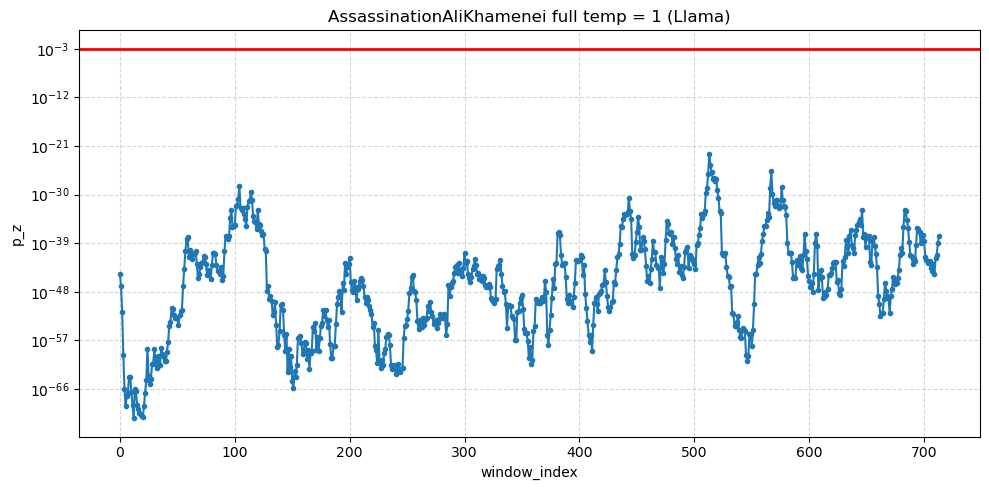

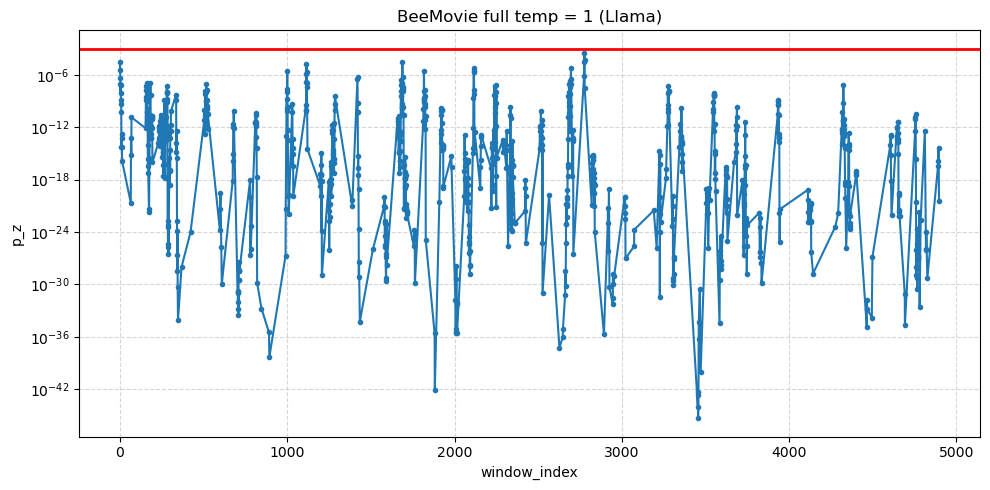

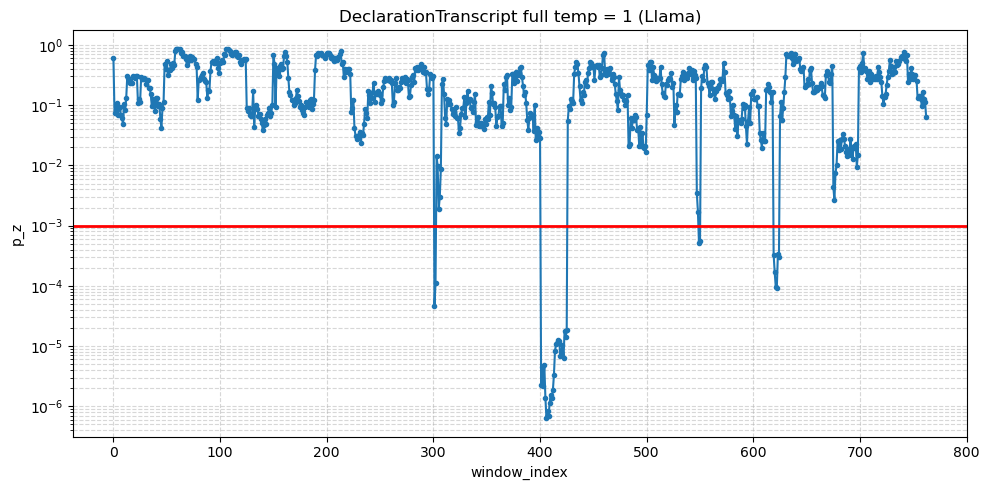

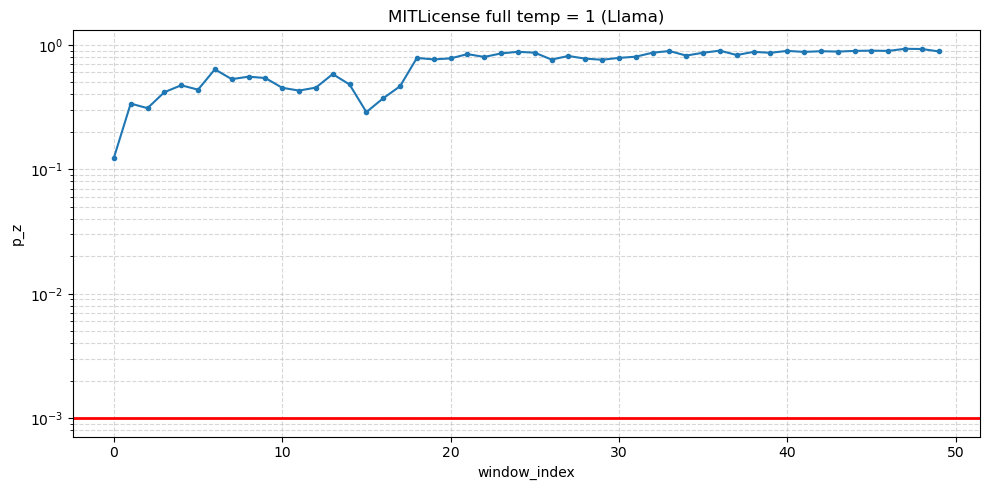

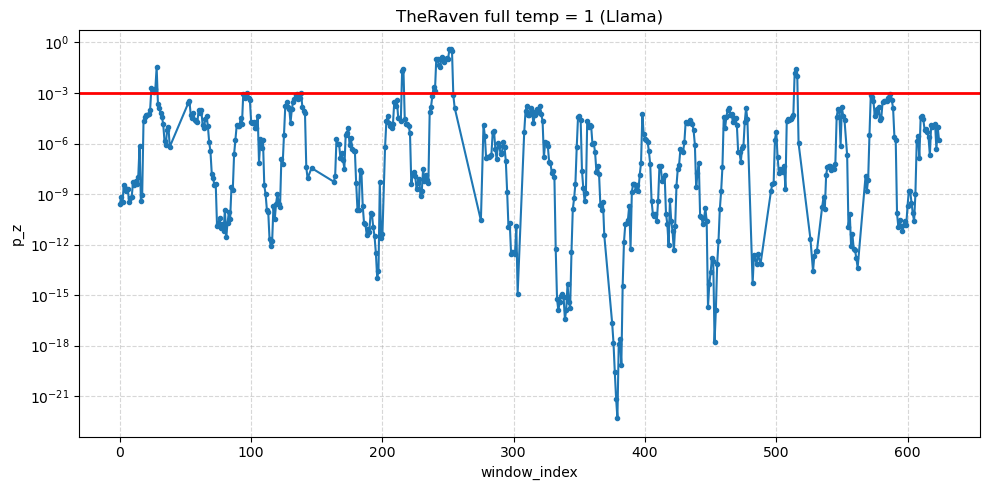

00000000000000000000 AssassinationAliKhamenei top_k = 40 temp = 1 (Llama)
00000000000000000000 BeeMovie top_k = 40 temp = 1 (Llama)
00000000000000000000 DeclarationTranscript top_k = 40 temp = 1 (Llama)
00000000000000000000 MITLicense top_k = 40 temp = 1 (Llama)
00000000000000000000 TheRaven top_k = 40 temp = 1 (Llama)


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


results_dir = Path("results")

summary_paths = sorted(results_dir.rglob("summary.json"))

if not summary_paths:
    print("No summary.json files found under results/")

for summary_path in summary_paths:
    rel_parts = summary_path.relative_to(results_dir).parts
    # Example:
    # ("LLaDA", "ELBO", "AssassinationAliKhamenei", "summary.json")

    folder_parts = rel_parts[:-1]  # drop "summary.json"
    if not folder_parts:
        continue

    # Title rule:
    # reverse folders, with the first original folder in parentheses at the end
    # e.g. LLaDA / ELBO / AssassinationAliKhamenei -> "AssassinationAliKhamenei ELBO (LLaDA)"
    if len(folder_parts) == 1:
        title = folder_parts[0]
    else:
        title = " ".join(folder_parts[:0:-1]) + f" ({folder_parts[0]})"

    # If title contains character "0", do not plot
    if "0" in title:
        print("0" * 20, title)
        continue

    windows_csv = summary_path.parent / "windows.csv"
    if not windows_csv.exists():
        print(f"Missing windows.csv for: {title}")
        continue

    try:
        df = pd.read_csv(windows_csv)
    except Exception as e:
        print(f"Could not read {windows_csv}: {e}")
        continue

    required_cols = {"window_index", "p_z"}
    if not required_cols.issubset(df.columns):
        print(f"Skipping {title}: missing columns {required_cols - set(df.columns)}")
        continue

    # Clean numeric data
    df = df.copy()
    df["window_index"] = pd.to_numeric(df["window_index"], errors="coerce")
    df["p_z"] = pd.to_numeric(df["p_z"], errors="coerce")
    df = df.dropna(subset=["window_index", "p_z"])

    if df.empty:
        print(f"Skipping {title}: no valid data")
        continue

    # Log scale cannot display <= 0
    df = df[df["p_z"] > 0]
    if df.empty:
        print(f"Skipping {title}: no positive p_z values for log scale")
        continue

    plt.figure(figsize=(10, 5))
    plt.plot(df["window_index"], df["p_z"], marker="o", markersize=3)
    plt.axhline(0.001, color="red", linestyle="-", linewidth=2)
    plt.yscale("log")
    plt.xlabel("window_index")
    plt.ylabel("p_z")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()